# Exercise 6.3: Neural Networks in Keras

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# See https://keras.io/
# for extennsive documentation
import tensorflow as tf
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Dense

plt.style.use("seaborn-v0_8")

Let us visit the problem of wine quality prediction previously encountered one final time. After linear regression and a self-made network, we can now explore the comfort provided by the Keras library.

In [11]:
# The code snippet below is responsible for downloading the dataset to
# Google. You can directly download the file using the link
# if you work with a local anaconda setup
#!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv --no-check-certificate

In [12]:
# load all examples from the file
data = np.genfromtxt("data/winequality-white.csv", delimiter=";", skip_header=1)

print(f"{data.shape = } \n")

# Prepare for proper training
rng = np.random.default_rng(1234)
rng.shuffle(data)  # randomly sort examples

# take the first 3000 examples for training
# (remember array slicing from last week)
X_train = data[:3000, :11]  # all features except last column
y_train = data[:3000, 11]  # quality column

# and the remaining examples for testing
X_test = data[3000:, :11]  # all features except last column
y_test = data[3000:, 11]  # quality column

print("First example:")
print("Features:", X_train[0])
print("Quality:", y_train[0])

data.shape = (4898, 12) 

First example:
Features: [6.8000e+00 1.9000e-01 7.1000e-01 1.7500e+01 4.2000e-02 2.1000e+01
 1.1400e+02 9.9784e-01 2.8500e+00 5.0000e-01 9.5000e+00]
Quality: 6.0


Below is the simple network from exercise 4.1 implemented using Keras. In addition to the network we define the loss function and optimiser.

In [13]:
# See: https://keras.io/api/models/sequential/ and
# https://keras.io/api/layers/core_layers/dense/
# We can use the Sequential class to very easiliy
# build a simple architecture
model = Sequential()
# 11 inputs, 20 outputs, relu
model.add(Dense(128, input_dim=11, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
# 20 inputs (automatically detected by Keras), 1 output, linear activation
model.add(Dense(1, activation='linear'))


adam = keras.optimizers.Adam(learning_rate=0.001)
print(model.summary())
# Set loss function and optimiser algorithm
model.compile(
    loss='mse',  # mean squared error
    optimizer='adam'# stochastic gradient descent
)

/opt/anaconda3/envs/mainenv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 0 (0.00 B)

None


# Training and evaluation below

The code below trains the network for 5 epochs using the loss function and optimiser defined above. Each example is individually passed to the network

In [14]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=100, batch_size=5)


Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step - loss: 1.6743 - val_loss: 1.2549
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - loss: 0.8323 - val_loss: 0.6184
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step - loss: 0.7995 - val_loss: 1.2178
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - loss: 0.7660 - val_loss: 0.6135
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - loss: 0.7545 - val_loss: 0.6034
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - loss: 0.7043 - val_loss: 0.7383
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - loss: 0.7154 - val_loss: 0.5971
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - loss: 0.7298 - val_loss: 0.6134
Epoch 9/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - loss: 0.6918 - val_loss: 0.6117
Epoch 10/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - loss: 0.6631 - val_loss: 0.5554
Epoch 11/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step - loss: 0.6729 - val_loss: 0.6031
Epoch 12/100
600/60

In [15]:
# The history object returned by the model training above
# contains the values of the loss function (the mean-squared-error)
# at different epochs
# We discard the first epoch as the loss value is very high,
# obscuring the rest of the distribution
train_loss = history.history["loss"][1:]
test_loss = history.history["val_loss"][1:]

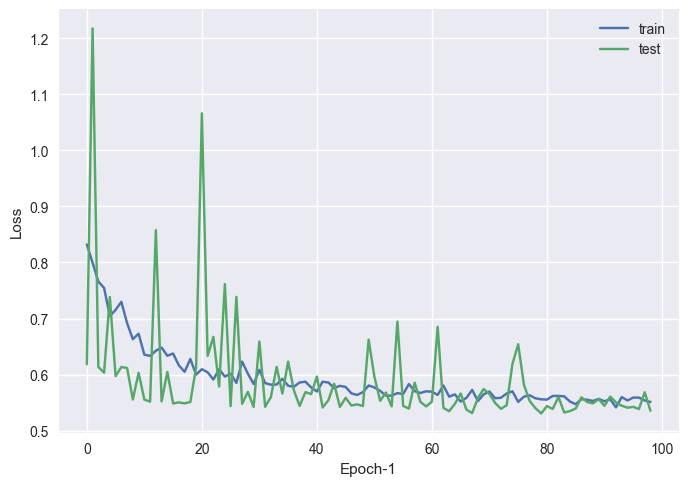

In [16]:
# Prepare and plot loss over time
plt.plot(train_loss,label="train")
plt.plot(test_loss,label="test")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Loss")
plt.show()

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step
Correlation coefficient: 0.5532598545843168


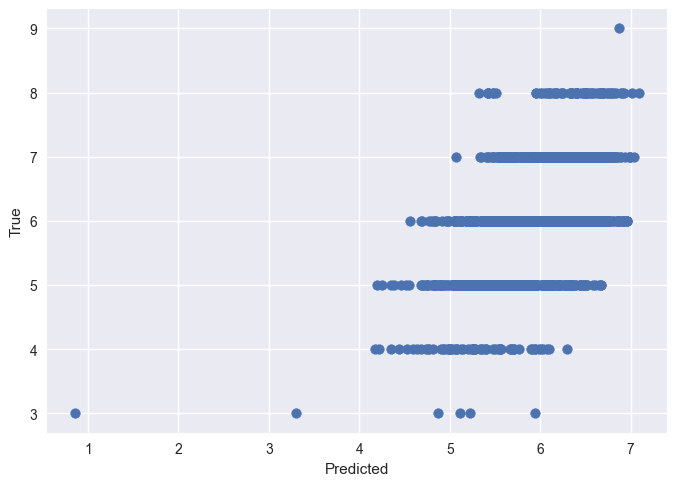

In [17]:
# After the training:

# Prepare scatter plot
y_pred = model.predict(X_test)[:,0]

print("Correlation coefficient:", np.corrcoef(y_pred,y_test)[0,1])
plt.scatter(y_pred,y_test)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [18]:
np.corrcoef(y_pred,y_test)

array([[1.        , 0.55325985],
       [0.55325985, 1.        ]])


# Problems

* Use the notebook as starting point. It already contains the simple network from Exercise 4.1 implemented in Keras.

* Currently, SGD is used without momentum. Try training with a momentum term. Replace SGD with the Adam optimizer and train using that. (See: https://keras.io/api/optimizers/)
* Add two more hidden layers to the network (you can choose the number of nodes but make sure to apply the ReLu activation function after each) and train again.
* Test differet numbers of examples (i.e. change the batch batch size) to be simulataneously used by the network.
* (bonus) optimize the network architecture to get the best correlation coefficient. (Let's see who gets the most out of the data).

### Train with Adam optimizer (lr = 0.001) : coeff = 0.533

### Train by changing network structure : coeff = 0.555

2 hidden layers with 20 nodes for each layer

### Train with batch_size = 5 : coeff = 0.555

## Try to optimize but its still not good :(